In [1]:
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import shap

In [2]:
# --- CONFIGURACIÓN ---
DATOS_ENTRENAMIENTO = 50000 # Prueba con 500, 5000 y 50000
NUM_EPOCHS = 10 # Vueltas al libro de datos
# ------------------------------------
# Carga de datos MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train_exp = np.expand_dims(x_train / 255.0, axis=-1)
x_test_exp = np.expand_dims(x_test / 255.0, axis=-1)
# Definición del modelo (Red Neuronal Básica)
model = tf.keras.Sequential([tf.keras.layers.Flatten(input_shape=(28, 28, 1)), tf.keras.layers.Dense(32, activation='relu'), tf.keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [3]:
# Entrenamiento
history = model.fit( x_train_exp[:DATOS_ENTRENAMIENTO], y_train[:DATOS_ENTRENAMIENTO], epochs=NUM_EPOCHS, validation_split=0.2, verbose=1)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8787 - loss: 0.4320 - val_accuracy: 0.9159 - val_loss: 0.2882
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9353 - loss: 0.2292 - val_accuracy: 0.9347 - val_loss: 0.2257
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9475 - loss: 0.1809 - val_accuracy: 0.9381 - val_loss: 0.2175
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9551 - loss: 0.1515 - val_accuracy: 0.9457 - val_loss: 0.1908
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9613 - loss: 0.1344 - val_accuracy: 0.9485 - val_loss: 0.1806
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9643 - loss: 0.1189 - val_accuracy: 0.9515 - val_loss: 0.1668
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9682 - loss: 0.1071 - val_accuracy: 0.9506 - val_loss: 0.1671
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9711 - loss: 0.0979 - 

**Pregunta: Observa el progreso de entrenamiento en pantalla. ¿Ves
cómo la pérdida (loss) baja mientras la precisión (accuracy) sube?**

Si, se puede observar que hay una subida exponencial en ambos valores, los de perdida cada vez se van acercando al 0 mientras la precisión va acercándose al 1.

**¿Ocurre al mismo ritmo en el entrenamiento que en la validación?**

No, varían bastante en ritmo, incluso llega a bajar la validación de precisión cuando estaba subiendo, pero mas o menos va creciendo exponencialmente pero de manera mas lenta.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step   


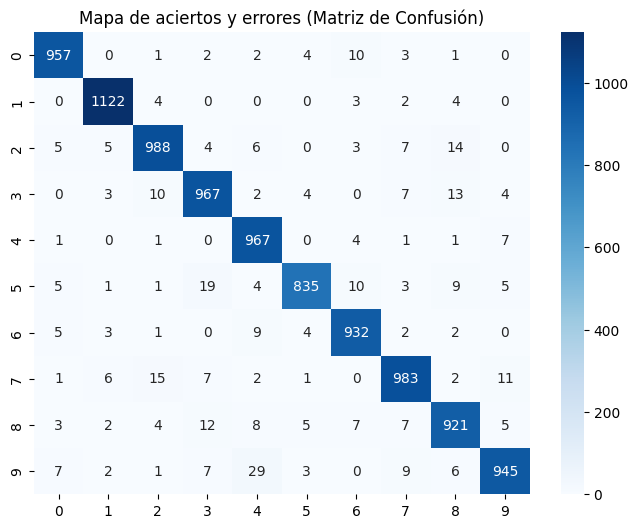


REPORTE FINAL:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       980
           1       0.98      0.99      0.98      1135
           2       0.96      0.96      0.96      1032
           3       0.95      0.96      0.95      1010
           4       0.94      0.98      0.96       982
           5       0.98      0.94      0.96       892
           6       0.96      0.97      0.97       958
           7       0.96      0.96      0.96      1028
           8       0.95      0.95      0.95       974
           9       0.97      0.94      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [4]:
preds = np.argmax(model.predict(x_test_exp), axis=1)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues')
plt.title("Mapa de aciertos y errores (Matriz de Confusión)")
plt.show()
print("\nREPORTE FINAL:")
print(classification_report(y_test, preds))

**Pregunta: Copia la Matriz de Confusión resultante. ¿Qué pareja de
números es la que más confunde el modelo?**

El modelo confunde bastante los numeros 3 con el 5, el 4 con el 9 y el 9 con el 4 y el 7.

**¿Por qué crees que ocurre visualmente?**

Ocurrirá porque se parecerán en su forma

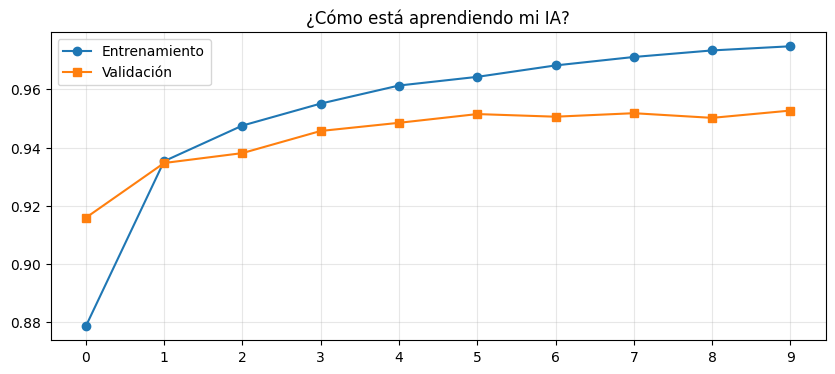

In [5]:
# Gráfica de progreso
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Entrenamiento', marker='o')
plt.plot(history.history['val_accuracy'], label='Validación', marker='s')
plt.title("¿Cómo está aprendiendo mi IA?")
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Pregunta: Si la línea naranja se estanca mientras la azul sigue
subiendo, ¿qué le está pasando al modelo?

Porque tiene overfitting

Pregunta: Si evaluamos con NUM_EPOCHS = 20, vemos que la
precisión alcanza el 100%. ¿Crees que hemos mejorado el sistema?

No, se ha agravado el overfitting ya que memoriza todo.

Pregunta: Amplía los datos a 20,000 y ajusta las épocas hasta obtener un F1-score superior al 0.95. ¿Cómo ha cambiado la forma de la gráfica respecto al modelo inicial?

Que tanto la validacion como el entrenamiento van casi parejos.

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 28, 28, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 28, 28, 1))']
  warnings.warn(msg)


Número real: 7


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 28, 28, 1))']
  warnings.warn(msg)


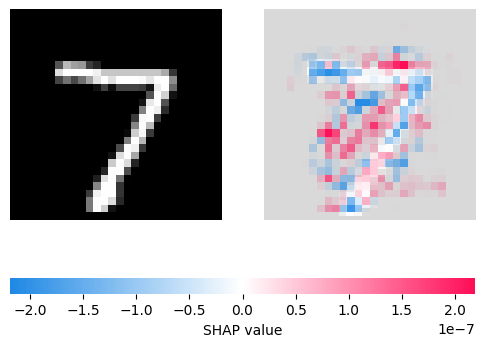

In [6]:
# Explicar un ejemplo (el primer 7 del test)
idx = 0
explainer = shap.DeepExplainer(model, x_train_exp[:100])
shap_values = explainer.shap_values(x_test_exp[idx:idx+1])
print(f"Número real: {y_test[idx]}")
shap.image_plot(shap_values, x_test_exp[idx:idx+1])

Pregunta: ¿En cuál de los dos ves áreas de color más definidas sobre el trazo del número? (Un modelo malo suele ver "fantasmas" o ruido en el fondo blanco).

Se ven mas areas de color en lade 50.000 datos de entrenamiento

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(10, 28, 28, 1))']
  warnings.warn(msg)


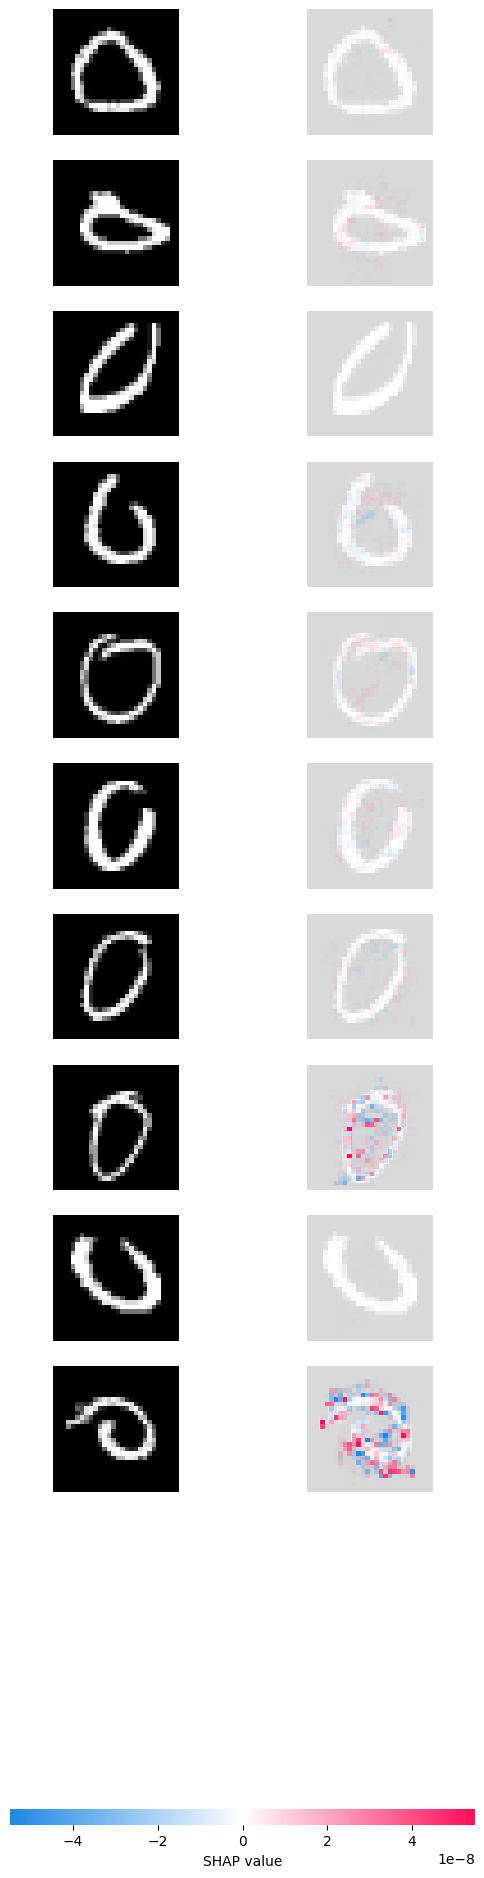

Ejemplo 1: Real 0 | IA dijo 3
Ejemplo 2: Real 0 | IA dijo 6
Ejemplo 3: Real 0 | IA dijo 6
Ejemplo 4: Real 0 | IA dijo 6
Ejemplo 5: Real 0 | IA dijo 5
Ejemplo 6: Real 0 | IA dijo 6
Ejemplo 7: Real 0 | IA dijo 2
Ejemplo 8: Real 0 | IA dijo 7
Ejemplo 9: Real 0 | IA dijo 6
Ejemplo 10: Real 0 | IA dijo 4


In [7]:
# Detectar imágenes que eran "0" pero la IA falló
idx_errores = np.where((y_test == 0) & (preds != 0))[0]
if len(idx_errores) > 0:
  sel = idx_errores[:10] # Ver 3 ejemplos
  shap_vals_err = explainer.shap_values(x_test_exp[sel])
  shap.image_plot(shap_vals_err, x_test_exp[sel])
  for i, s in enumerate(sel):
    print(f"Ejemplo {i+1}: Real 0 | IA dijo {preds[s]}")


Pregunta: Mira un ejemplo donde la IA falló. ¿Es un número mal
escrito que incluso a un humano le costaría leer, o es un error tonto de la IA?

Es un error tonto de la IA

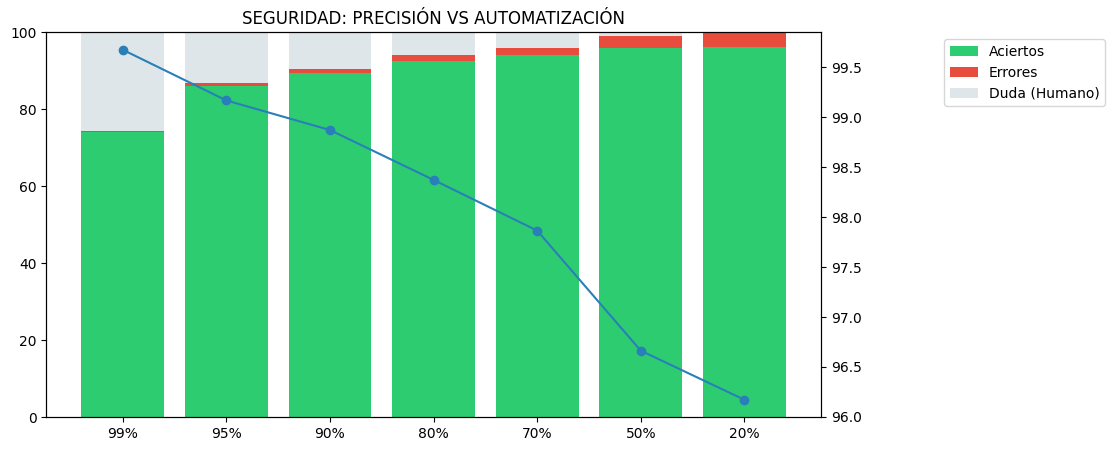

In [8]:
# 1. Predicciones y comparativa
probs = model.predict(x_test_exp, verbose=0)
conf, preds = np.max(probs, axis=1), np.argmax(probs,
axis=1)
correctos = (preds == y_test)

# 2. Cálculo de métricas por umbral
umbrales = [0.99, 0.95, 0.90, 0.80, 0.70, 0.50, 0.20]
res = []
for u in umbrales:
  pasan = conf >= u
  n = np.sum(pasan)
  aciertos = np.sum(correctos[pasan]) if n > 0 else 0
  res.append([u*100, (aciertos/100), (n-aciertos)/100, (10000-n)/100, (aciertos/n*100 if n>0 else 100)])
df = pd.DataFrame(res, columns=['U', 'A', 'F', 'D', 'P'])

# 3. Gráfica optimizada
fig, ax1 = plt.subplots(figsize=(10, 5))
x = range(len(df))
ax1.bar(x, df['A'], color='#2ecc71', label='Aciertos')
ax1.bar(x, df['F'], bottom=df['A'], color='#e74c3c', label='Errores')
ax1.bar(x, df['D'], bottom=df['A']+df['F'], color='#dfe6e9', label='Duda (Humano)')
ax2 = ax1.twinx()
ax2.plot(x, df['P'], color='#2980b9', marker='o', label='Calidad IA')
11
ax1.set_xticks(x)
ax1.set_xticklabels([f"{int(i)}%" for i in df['U']])
ax1.set_title("SEGURIDAD: PRECISIÓN VS AUTOMATIZACIÓN")
ax1.legend(loc='upper left', bbox_to_anchor=(1.15, 1))
plt.show()


Pregunta: Si estableces un umbral del 99%, ¿qué porcentaje de
imágenes tiene que revisar un humano (Descartes)?

Tendria que revisar un 22%

¿Qué umbral elegirías para una aplicación donde un error es muy grave, pero no tienes mucho personal humano para revisar?

Elegiría el del 70% de umbral

In [9]:
# Guardamos el modelo entrenado en formato (.h5)
model.save('modelo_mnist.h5')